### Librerias

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from math import pi
import random

# Configuración inicial para mejorar la estética de los gráficos
sns.set_theme(style="whitegrid")

### Lectura de datos


In [ ]:
df = pd.read_csv('resultados/simulaciones_conversacion_resultados.csv')
df = df.drop(columns=['mentescopin', 'youth'])

In [14]:
df.head()

,temperature,top_p,top_k,model_psy,condicion,tipo_pensamiento,model_youth,emotional_entropy,emotional_matching,agreeableness,linguistic_matching,empathy
0,0.2,0.7,10,llama3,Adicciones,Negativo,llama3,0.578051,0.421948,0.531692,0.551686,0.555556
1,0.2,0.7,10,llama3,Adicciones,Positivo,llama3,0.820712,0.547244,0.521546,0.602225,0.388889
2,0.2,0.7,10,llama3,Adicciones,Negativo,llama3,0.831169,0.371561,0.475771,0.641914,0.222222
3,0.2,0.7,10,llama3,Adicciones,Negativo,llama3,0.765393,0.251470,0.512240,0.679562,0.222222
4,0.2,0.7,10,llama3,Adicciones,Positivo,llama3,0.658170,0.613744,0.514464,0.769761,0.333333


### Lista de métricas y configuraciones

In [15]:
METRICS = ['emotional_entropy', 'emotional_matching', 'agreeableness', 'linguistic_matching', 'empathy']
NUMERIC_CONFIGS = ['temperature', 'top_p', 'top_k']
CATEGORICAL_CONFIGS = ['model_psy', 'condicion', 'tipo_pensamiento']

### Pruebas Estadísticas

Para cuantificar las observaciones de los gráficos, realizaremos dos tipos de pruebas estadísticas:

1.  **Prueba de Kruskal-Wallis (no paramétrica):** Para determinar si existen diferencias estadísticamente significativas en las métricas entre los diferentes grupos de las variables categóricas (ej. `model_psy`, `condicion`).
2.  **Correlación de Spearman:** Para medir la fuerza y la dirección de la asociación entre las métricas y las variables numéricas (`temperature`, `top_p`, `top_k`).

Un **p-valor < 0.05** generalmente se considera estadísticamente significativo.

In [16]:
from scipy.stats import kruskal, spearmanr

def run_statistical_tests(df, metrics, cat_vars, num_vars):
    # --- Prueba de Kruskal-Wallis para variables categóricas ---
    print("--- Resultados de la Prueba de Kruskal-Wallis (p-valor < 0.05 es significativo) ---")
    kruskal_results = []
    for cat_var in cat_vars:
        for metric in metrics:
            # Agrupar los datos por la variable categórica
            groups = [group[metric].dropna() for name, group in df.groupby(cat_var)]
            
            # Realizar la prueba de Kruskal-Wallis si hay al menos 2 grupos
            if len(groups) > 1:
                stat, p_value = kruskal(*groups)
                kruskal_results.append({
                    'Métrica': metric,
                    'Variable Categórica': cat_var,
                    'Estadístico H': stat,
                    'p-valor': p_value
                })
    
    kruskal_df = pd.DataFrame(kruskal_results)
    display(kruskal_df.sort_values('p-valor').reset_index(drop=True))

    # --- Correlación de Spearman para variables numéricas ---
    print("\n--- Resultados de la Correlación de Spearman (p-valor < 0.05 es significativo) ---")
    spearman_results = []
    for num_var in num_vars:
        for metric in metrics:
            # Eliminar NaNs para la correlación
            clean_df = df[[num_var, metric]].dropna()
            corr, p_value = spearmanr(clean_df[num_var], clean_df[metric])
            spearman_results.append({
                'Métrica': metric,
                'Variable Numérica': num_var,
                'Coeficiente de Correlación (rho)': corr,
                'p-valor': p_value
            })
            
    spearman_df = pd.DataFrame(spearman_results)
    display(spearman_df.sort_values('p-valor').reset_index(drop=True))

# Ejecutar las pruebas estadísticas
run_statistical_tests(df, METRICS, CATEGORICAL_CONFIGS, NUMERIC_CONFIGS)

--- Resultados de la Prueba de Kruskal-Wallis (p-valor < 0.05 es significativo) ---


,Métrica,Variable Categórica,Estadístico H,p-valor
0,empathy,model_psy,378.945621,2.111140e-84
1,agreeableness,model_psy,275.458275,7.334071e-62
2,emotional_matching,tipo_pensamiento,201.439232,9.372339e-41
3,linguistic_matching,tipo_pensamiento,138.429246,2.149733e-27
4,linguistic_matching,model_psy,77.201099,1.544076e-18
5,linguistic_matching,condicion,84.736835,8.547519e-17
6,emotional_entropy,condicion,80.060452,8.150971e-16
7,emotional_entropy,tipo_pensamiento,75.654750,2.813933e-14
8,agreeableness,condicion,72.144543,3.664937e-14
9,agreeableness,tipo_pensamiento,71.787436,1.756913e-13



--- Resultados de la Correlación de Spearman (p-valor < 0.05 es significativo) ---


,Métrica,Variable Numérica,Coeficiente de Correlación (rho),p-valor
0,linguistic_matching,top_p,0.065801,0.005225
1,emotional_matching,top_p,0.049329,0.036379
2,emotional_matching,temperature,0.044519,0.058970
3,empathy,top_p,0.039948,0.090200
4,emotional_matching,top_k,0.037636,0.110436
5,empathy,temperature,0.035733,0.129662
6,linguistic_matching,temperature,0.034466,0.143824
7,emotional_entropy,top_p,0.027834,0.237881
8,empathy,top_k,0.025196,0.285344
9,agreeableness,top_k,0.010678,0.650748


### Distribución de Métricas por Configuraciones Categóricas (Box/Violin Plots)

Generando Gráficos de Caja/Violín para variables categóricas...


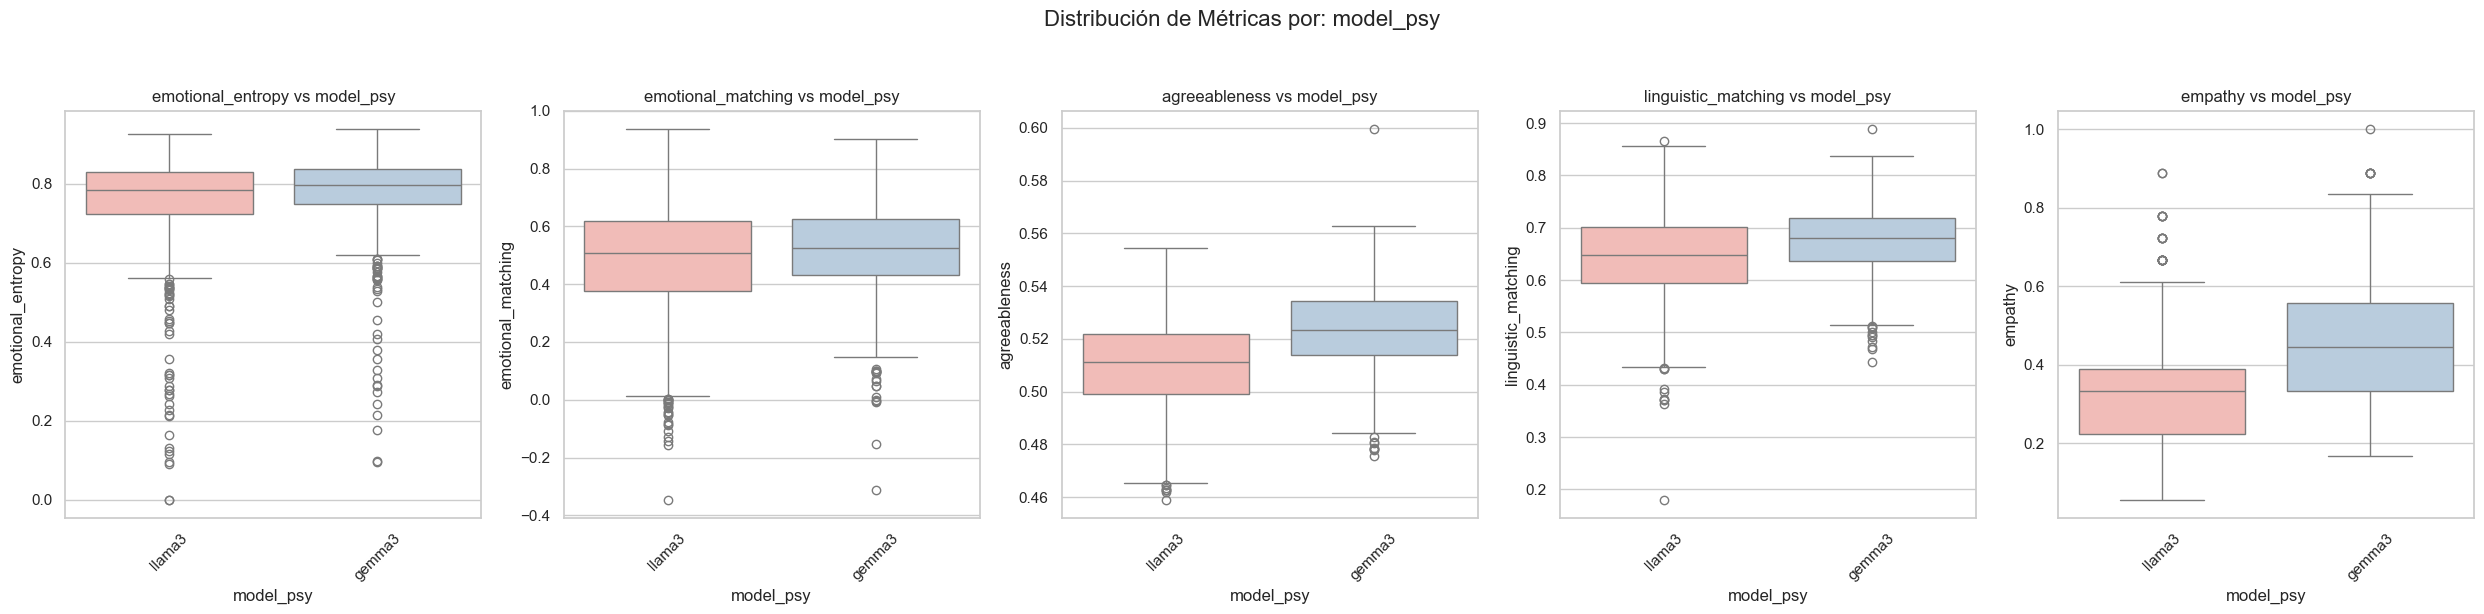

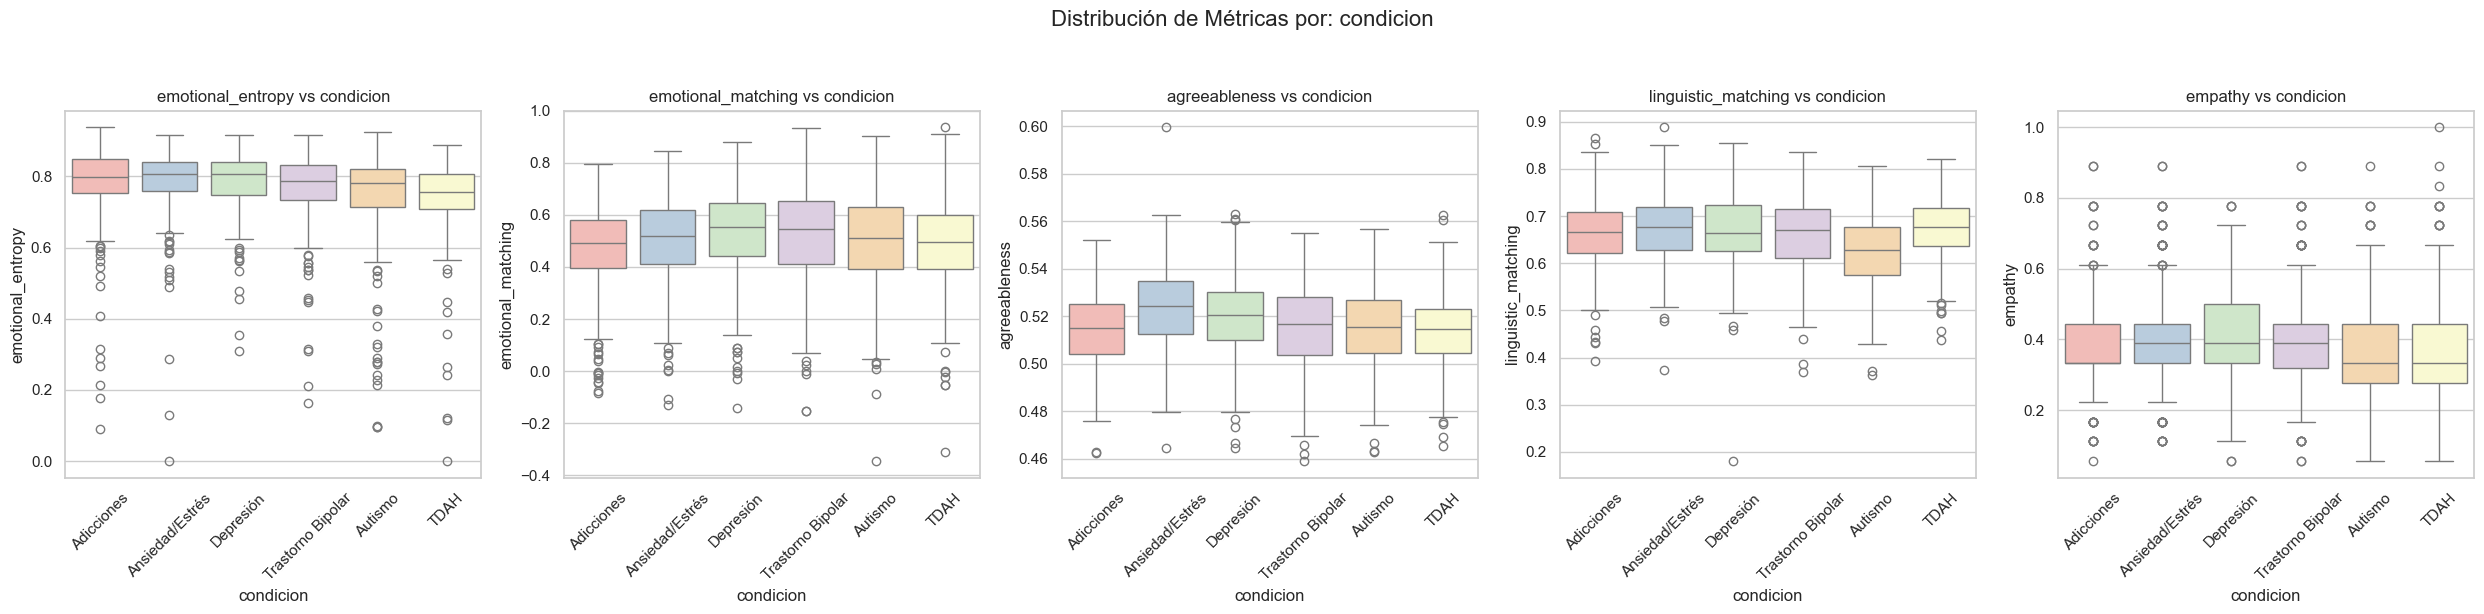

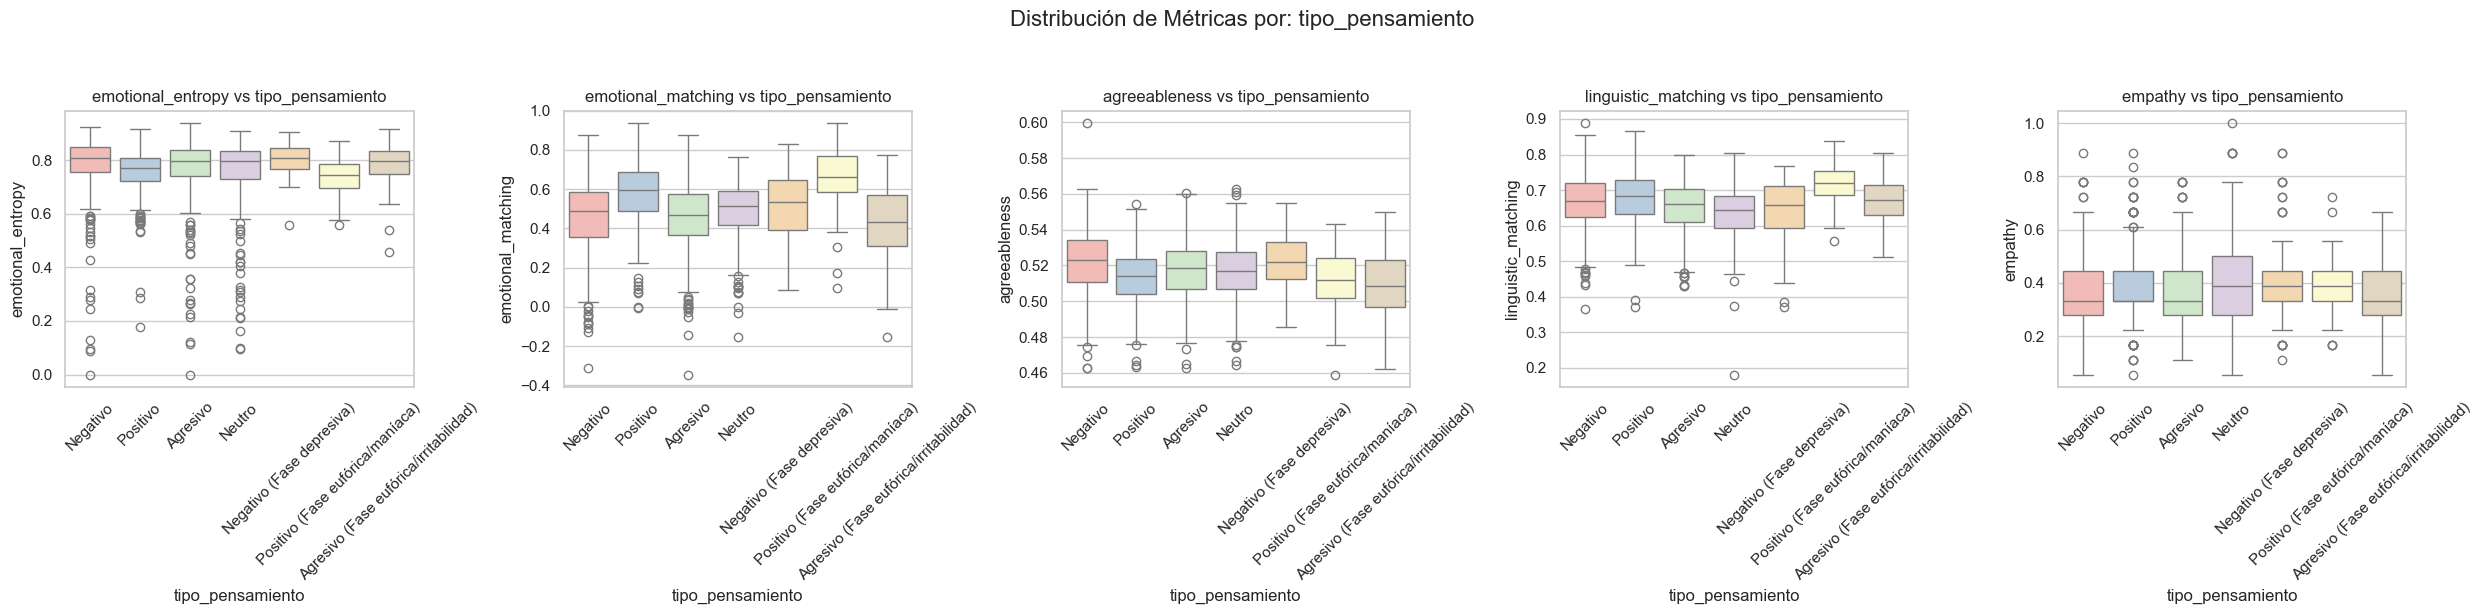

In [17]:
# Creamos una función para generar los gráficos de caja/violín de forma eficiente
def plot_categorical_vs_metrics(df, cat_vars, metrics):
    for cat_var in cat_vars:
        # Crea una figura con subplots para todas las métricas
        fig, axes = plt.subplots(nrows=1, ncols=len(metrics), figsize=(5 * len(metrics), 6))
        fig.suptitle(f'Distribución de Métricas por: {cat_var}', fontsize=16, y=1.02)
        
        for i, metric in enumerate(metrics):
            ax = axes[i]
            # Usamos Boxplot para ver la mediana, cuartiles y outliers
            sns.boxplot(x=cat_var, y=metric, data=df, ax=ax, palette="Pastel1", hue=cat_var, dodge=False, legend=False)
            
            # También puedes usar Violin Plot para ver la densidad de distribución
            # sns.violinplot(x=cat_var, y=metric, data=df, ax=ax, palette="Pastel2", hue=cat_var, dodge=False, legend=False)
            
            ax.set_title(f'{metric} vs {cat_var}')
            ax.set_ylabel(metric)
            ax.set_xlabel(cat_var)
            ax.tick_params(axis='x', rotation=45) # Rotar etiquetas para mejor lectura

        plt.tight_layout(rect=[0, 0, 1, 0.98]) # Ajustar diseño
        plt.show()

print("Generando Gráficos de Caja/Violín para variables categóricas...")
plot_categorical_vs_metrics(df, CATEGORICAL_CONFIGS, METRICS)

### Relación de Métricas con Configuraciones Numéricas (Line Plots)


Generando Gráficos de Línea para variables numéricas...


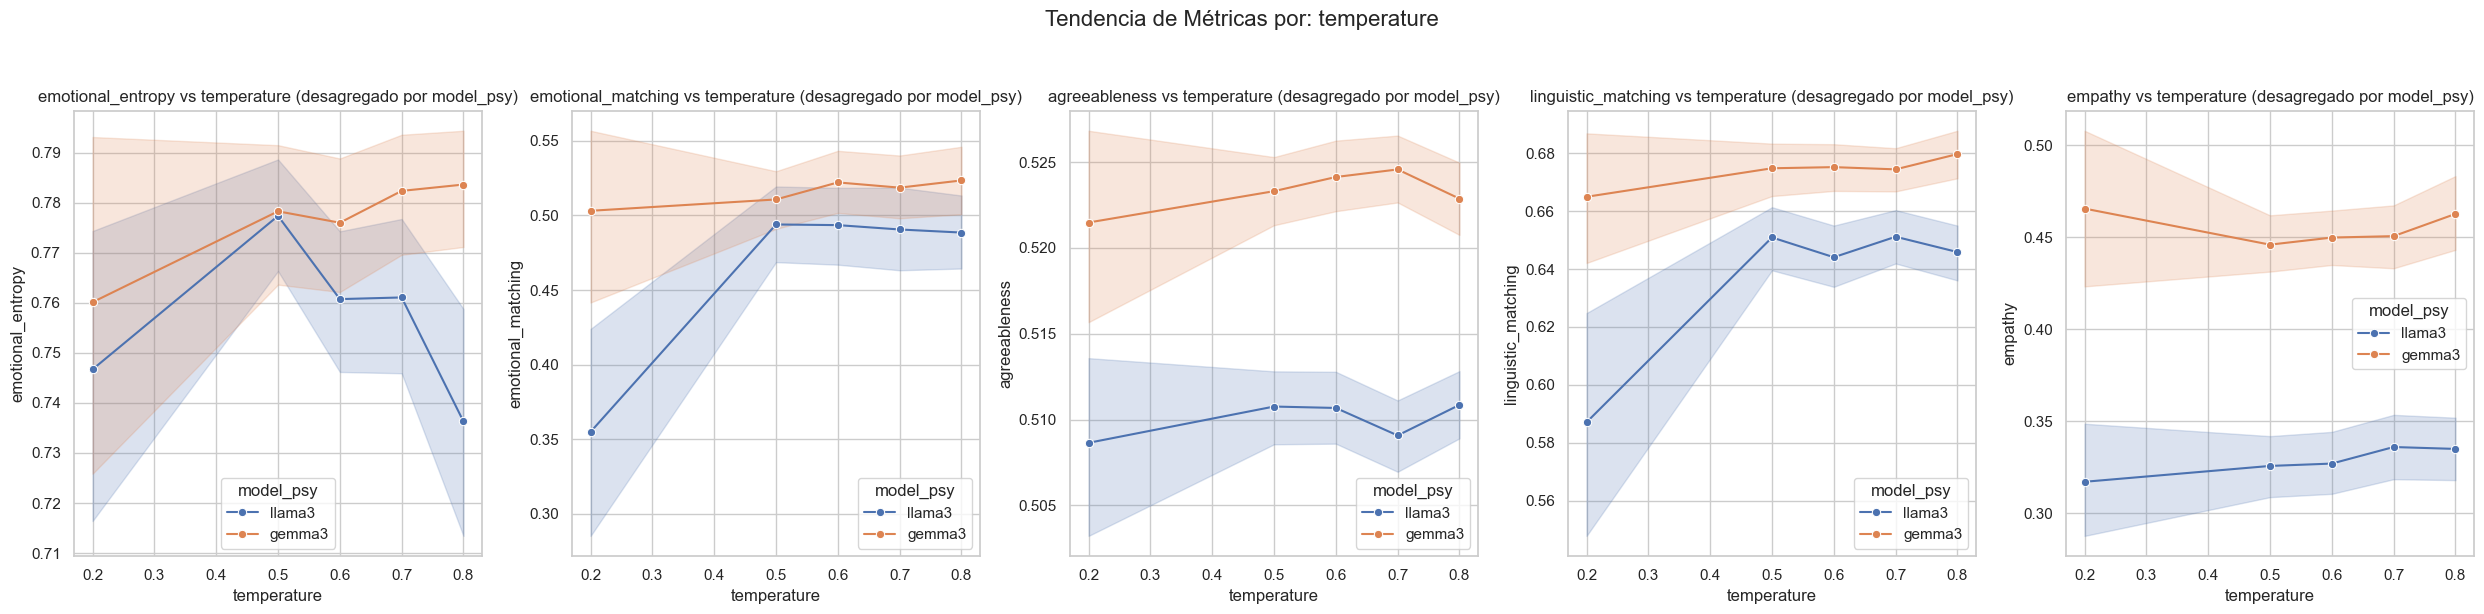

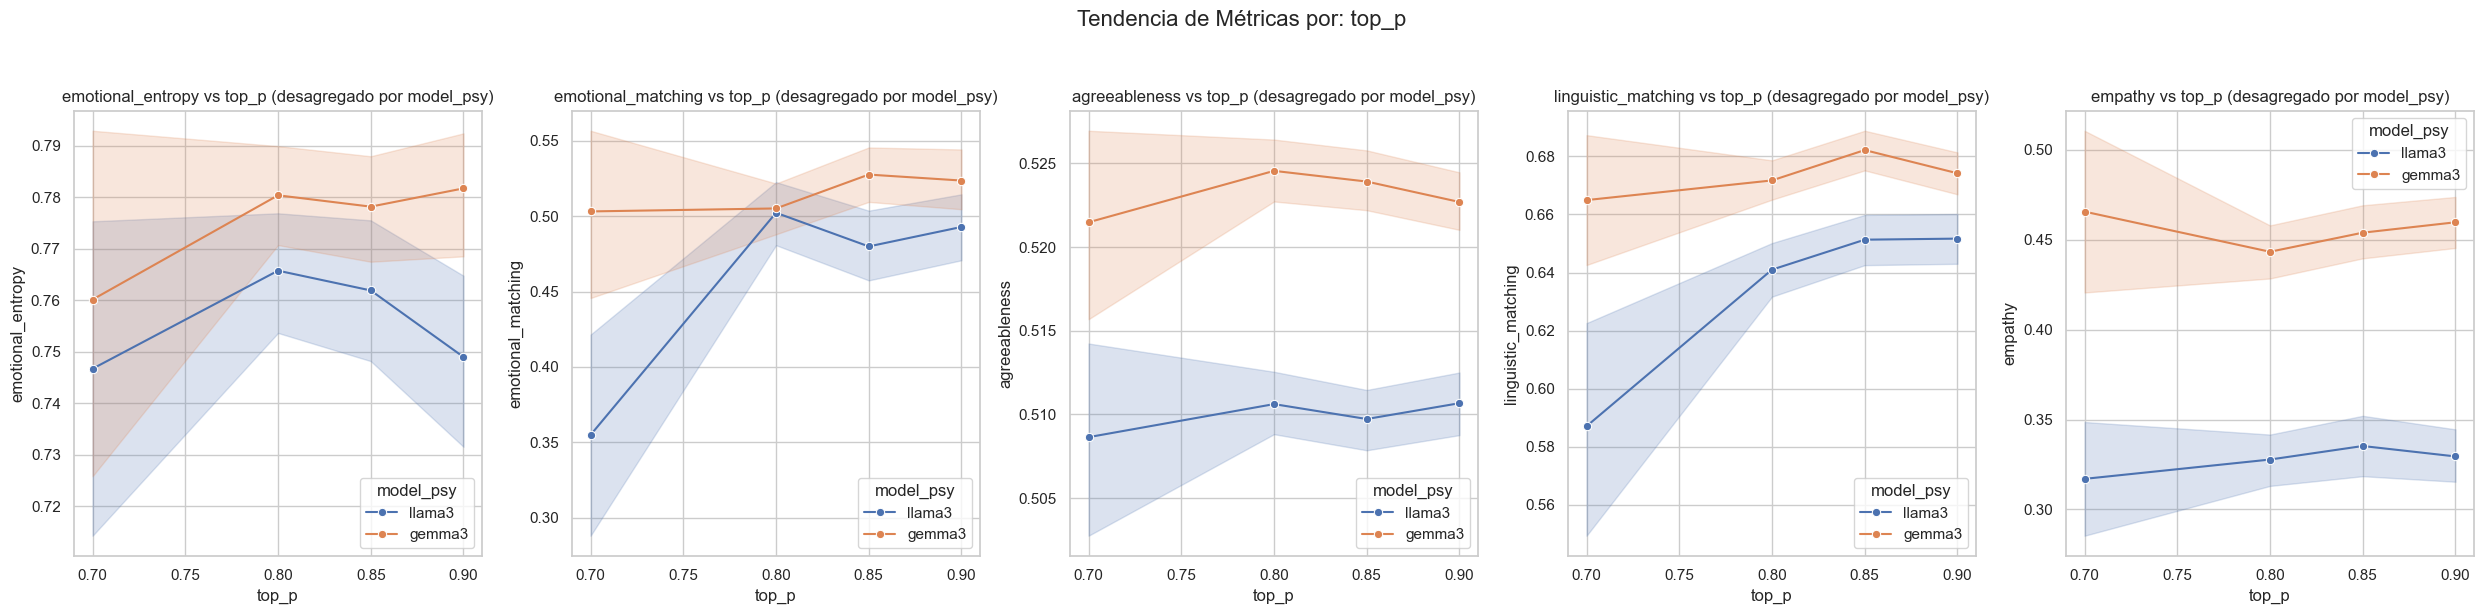

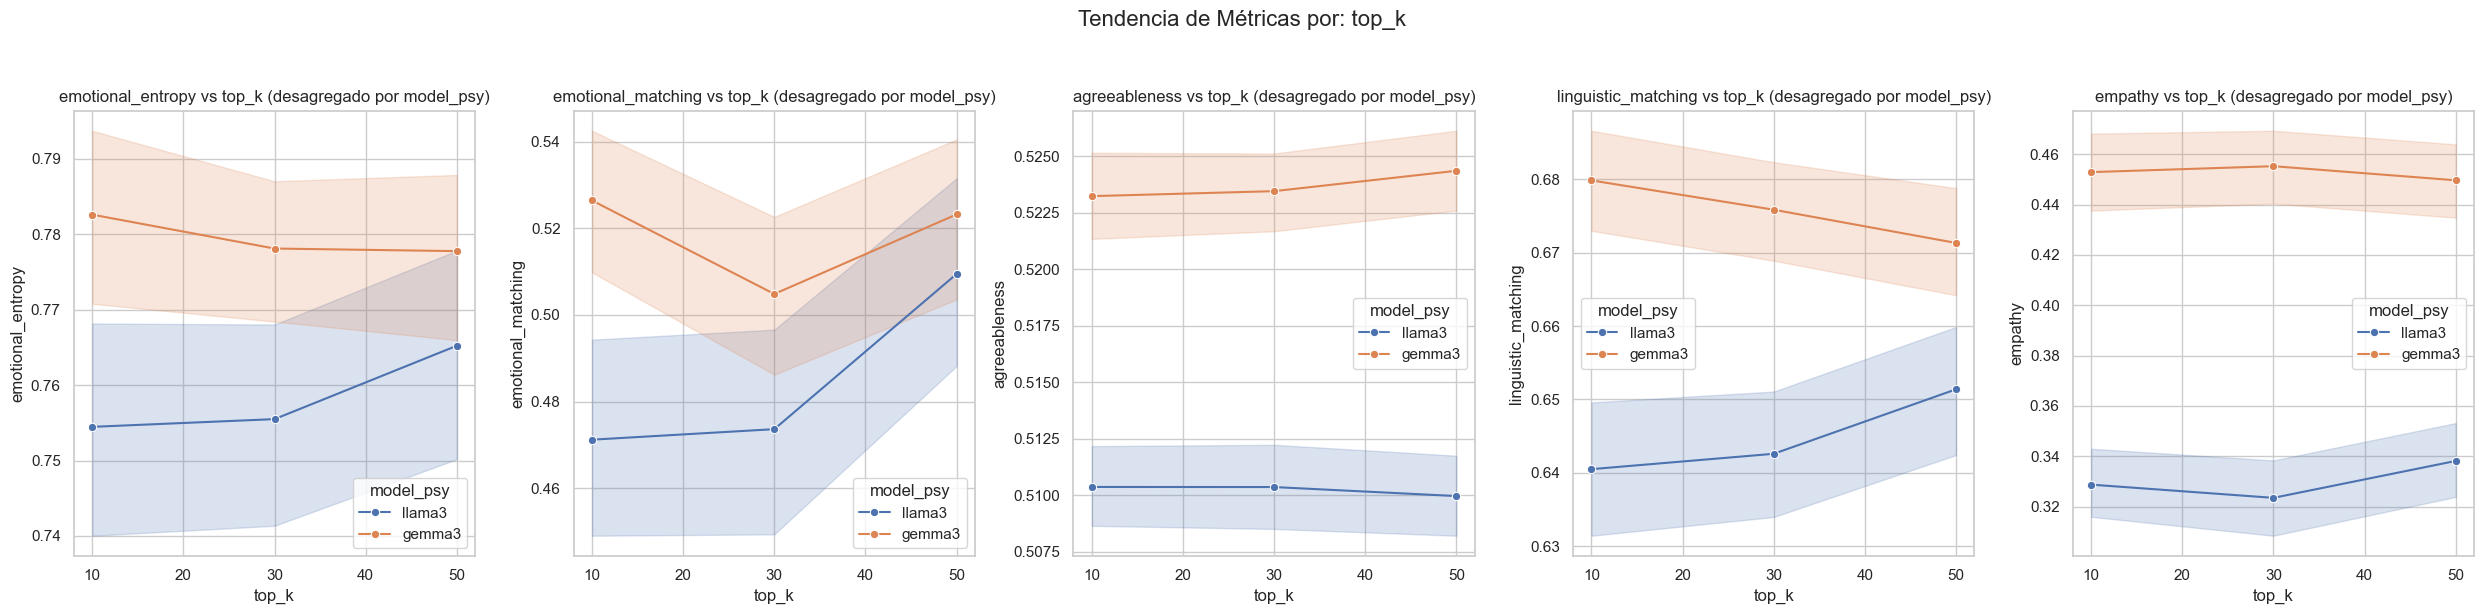

In [18]:
# Estas variables (temperature, top_p, top_k) tienen pocos valores discretos.
# Usar un gráfico de línea con error de barra es ideal para ver la tendencia media.
def plot_numeric_vs_metrics(df, num_vars, metrics):
    for num_var in num_vars:
        fig, axes = plt.subplots(nrows=1, ncols=len(metrics), figsize=(5 * len(metrics), 6))
        fig.suptitle(f'Tendencia de Métricas por: {num_var}', fontsize=16, y=1.02)
        
        for i, metric in enumerate(metrics):
            ax = axes[i]
            # Usa lineplot para mostrar la media (línea) y el intervalo de confianza (sombra)
            # 'hue' permite desagregar aún más, por ejemplo, por modelo
            sns.lineplot(x=num_var, y=metric, data=df, ax=ax, errorbar=('ci', 95), 
                         marker='o', hue='model_psy')
            
            ax.set_title(f'{metric} vs {num_var} (desagregado por model_psy)')
            ax.set_ylabel(metric)
            ax.set_xlabel(num_var)

        plt.tight_layout(rect=[0, 0, 1, 0.98])
        plt.show()

print("\nGenerando Gráficos de Línea para variables numéricas...")
plot_numeric_vs_metrics(df, NUMERIC_CONFIGS, METRICS)

### Visualización Radar Charts con valores minimos, medios y máximos de cada una de las métricas

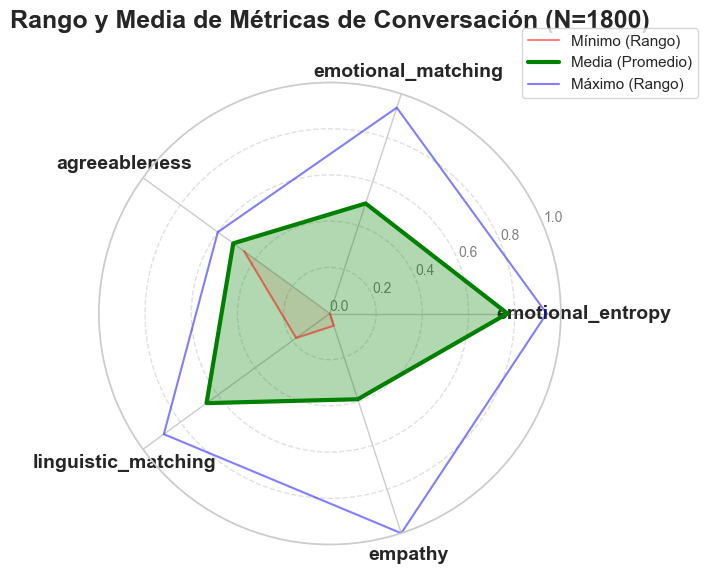

In [19]:
data_stats = df[METRICS].agg(['min', 'mean', 'max']).T

# Extraer los valores
min_values = data_stats['min'].values.flatten().tolist()
mean_values = data_stats['mean'].values.flatten().tolist()
max_values = data_stats['max'].values.flatten().tolist()

# Configuración de ángulos para el gráfico de radar
N = len(METRICS)
# Calcula los ángulos para cada eje
angles = [n / float(N) * 2 * pi for n in range(N)]
# Cierra el círculo añadiendo el primer ángulo y valor al final
angles += angles[:1] 

# Cierra el polígono para los valores también
min_values += min_values[:1]
mean_values += mean_values[:1]
max_values += max_values[:1]

# Crea el subplot polar
fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))

# Dibujar el Mínimo (Línea base)
ax.plot(angles, min_values, linewidth=1.5, linestyle='solid', 
        label='Mínimo (Rango)', color='red', alpha=0.5)
ax.fill(angles, min_values, 'red', alpha=0.1)

# Dibujar la Media (Tendencia central)
ax.plot(angles, mean_values, linewidth=3, linestyle='solid', 
        label='Media (Promedio)', color='green')
ax.fill(angles, mean_values, 'green', alpha=0.3)

# Dibujar el Máximo (Límite superior)
ax.plot(angles, max_values, linewidth=1.5, linestyle='solid', 
        label='Máximo (Rango)', color='blue', alpha=0.5)

# Configuración de Ejes y Etiquetas
ax.set_xticks(angles[:-1])
ax.set_xticklabels(METRICS, size=14, weight='bold')

# Establecer los límites del eje radial de 0 a 1
ax.set_yticks(np.arange(0, 1.1, 0.2)) 
ax.set_yticklabels([f'{val:.1f}' for val in np.arange(0, 1.1, 0.2)], 
                   color="gray", size=10)
ax.set_ylim(0, 1)

# Poner los ticks en el centro (opcional)
ax.yaxis.grid(True, linestyle='--', alpha=0.6)

# Título y Leyenda
plt.title('Rango y Media de Métricas de Conversación (N=1800)', 
          size=18, y=1.1, weight='bold')
ax.legend(loc='lower left', bbox_to_anchor=(0.9, 0.95))

plt.show()

### Visualización Radar Charts con un registro aleatorio 

In [20]:
# Seleccionar un registro aleatorio
random_index = random.randint(0, len(df) - 1)
registro_aleatorio = df.iloc[random_index]

registro_aleatorio

temperature                   0.5
top_p                         0.9
top_k                          50
model_psy                  gemma3
condicion              Adicciones
tipo_pensamiento         Negativo
model_youth                llama3
emotional_entropy        0.879018
emotional_matching       0.462209
agreeableness            0.501541
linguistic_matching       0.64905
empathy                       0.5
Name: 480, dtype: object

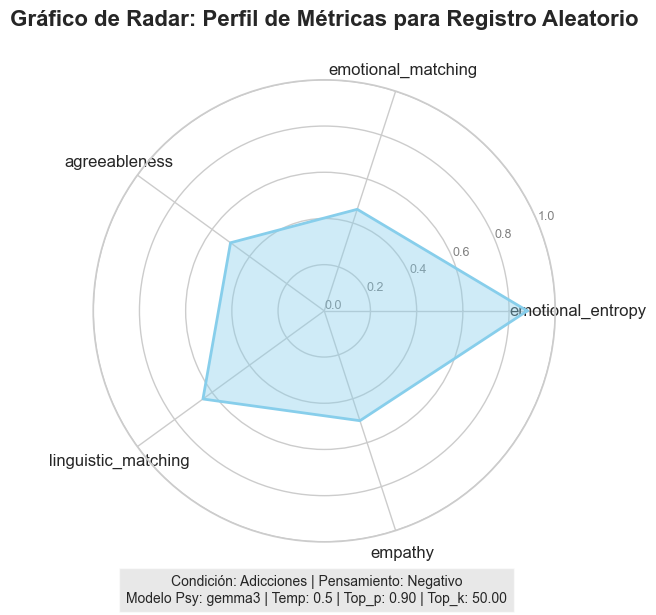

In [21]:
values = registro_aleatorio[METRICS].values.flatten().tolist()
# Los valores deben cerrarse, así que añadimos el primer valor al final
values += values[:1]

# Número de métricas
N = len(METRICS)

# Calcular los ángulos para cada eje (360/N)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

# Crear el subplot polar
fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))

# Dibujar la línea de la métrica y rellenar el área
ax.plot(angles, values, linewidth=2, linestyle='solid', label='Perfil de Registro', color='skyblue')
ax.fill(angles, values, 'skyblue', alpha=0.4)

# Establecer los límites y etiquetas de los ejes
ax.set_xticks(angles[:-1])
ax.set_xticklabels(METRICS, size=12)

# Establecer los límites del eje radial de 0 a 1
ax.set_yticks(np.arange(0, 1.1, 0.2)) 
ax.set_yticklabels([f'{val:.1f}' for val in np.arange(0, 1.1, 0.2)], color="gray", size=9)
ax.set_ylim(0, 1)

# Poner los ticks en el centro (opcional, pero mejora la estética)
ax.yaxis.grid(True)

# Información del registro para el título
info_registro = (
    f"Condición: {registro_aleatorio['condicion']} | "
    f"Pensamiento: {registro_aleatorio['tipo_pensamiento']}\n"
    f"Modelo Psy: {registro_aleatorio['model_psy']} | "
    f"Temp: {registro_aleatorio['temperature']:.1f} | "
    f"Top_p: {registro_aleatorio['top_p']:.2f} | "
    f"Top_k: {registro_aleatorio['top_k']:.2f}"
)

# Título
plt.title(f'Gráfico de Radar: Perfil de Métricas para Registro Aleatorio', 
          size=16, y=1.1, weight='bold')
plt.figtext(0.5, 0.01, info_registro, ha="center", fontsize=10, 
            bbox={"facecolor":"lightgray", "alpha":0.5, "pad":5})

plt.show()